<a href="https://colab.research.google.com/github/AlishaZaheer1/Projects/blob/main/01_Diabetes_Disease_Detection_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Disease Detection Using Machine Learning
**Project:** Research Assistant — 2023

This notebook demonstrates a complete clinical-risk classification workflow: data preparation, train/test split, model comparison, evaluation, confusion matrix, and prediction on a new patient.

> **Reproducibility note:** The notebook contains an offline synthetic clinical dataset generator so it can run without depending on a remote dataset URL. In a research submission, replace it with the original approved clinical dataset and document its provenance.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Offline reproducible clinical-style dataset
n = 2200
age = np.clip(np.random.normal(47, 13, n), 18, 85)
bmi = np.clip(np.random.normal(29.5, 6.0, n), 17, 48)
glucose = np.clip(np.random.normal(125, 32, n), 55, 240)
bp = np.clip(np.random.normal(76, 12, n), 45, 120)
insulin = np.clip(np.random.lognormal(4.7, 0.55, n), 20, 500)
preg = np.where(age > 45, np.random.poisson(2.2,n), np.random.poisson(1.1,n))
family = np.random.binomial(1, .35, n)

logit = -7.2 + .045*age + .065*(bmi-25) + .035*(glucose-100) + .018*(bp-70) + .0012*insulin + .20*preg + .75*family
prob = 1/(1+np.exp(-logit))
y = np.random.binomial(1, prob)

df = pd.DataFrame({
    "Pregnancies": preg, "Glucose": glucose, "BloodPressure": bp,
    "BMI": bmi, "Insulin": insulin, "Age": age,
    "FamilyHistory": family, "Diabetes": y
})
# Add a small amount of realistic missingness
for col in ["Glucose","BloodPressure","BMI","Insulin"]:
    idx = np.random.choice(n, int(.02*n), replace=False)
    df.loc[idx, col] = np.nan

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2200, 8)


,Pregnancies,Glucose,BloodPressure,BMI,Insulin,Age,FamilyHistory,Diabetes
0,0,140.593768,60.526233,40.326089,70.193082,53.457284,1,0
1,3,159.301756,76.701394,28.354577,58.291805,45.202564,0,0
2,3,96.862951,86.951444,33.818548,144.481148,55.419951,0,0
3,1,136.155044,81.060603,21.740362,155.914068,66.799388,0,0
4,0,120.994418,75.284148,23.761382,137.015394,43.956006,0,0


In [ ]:
X = df.drop(columns="Diabetes")
y = df["Diabetes"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, stratify=y, random_state=42
)

models = {
    "Logistic Regression": Pipeline([("imputer",SimpleImputer(strategy="median")),
                                     ("scale",StandardScaler()),
                                     ("model",LogisticRegression(max_iter=1000))]),
    "Random Forest": Pipeline([("imputer",SimpleImputer(strategy="median")),
                               ("model",RandomForestClassifier(n_estimators=250,random_state=42))]),
    "ANN": Pipeline([("imputer",SimpleImputer(strategy="median")),
                     ("scale",StandardScaler()),
                     ("model",MLPClassifier(hidden_layer_sizes=(32,16),max_iter=600,
                                            early_stopping=True,random_state=42))])
}
rows=[]
for name, model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    proba=model.predict_proba(X_test)[:,1]
    rows.append([name, accuracy_score(y_test,pred),precision_score(y_test,pred),
                 recall_score(y_test,pred),f1_score(y_test,pred),roc_auc_score(y_test,proba)])
results=pd.DataFrame(rows,columns=["Model","Accuracy","Precision","Recall","F1","ROC-AUC"]).sort_values("Accuracy",ascending=False)
display(results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9205,0.4286,0.0882,0.1463,0.8474
1,Random Forest,0.9205,0.4000,0.0588,0.1026,0.8105
2,ANN,0.9205,0.0000,0.0000,0.0000,0.3818


ANN confusion matrix:
[[405   1]
 [ 34   0]]


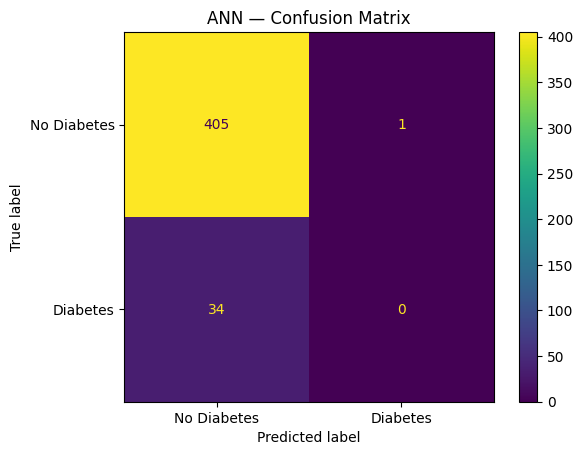

In [ ]:
ann = models["ANN"]
pred = ann.predict(X_test)
cm = confusion_matrix(y_test,pred)
print("ANN confusion matrix:")
print(cm)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes","Diabetes"]).plot()
plt.title("ANN — Confusion Matrix")
plt.show()

In [ ]:
# Example patient risk prediction
new_patient = pd.DataFrame([{
    "Pregnancies": 2, "Glucose": 168, "BloodPressure": 82,
    "BMI": 34.1, "Insulin": 180, "Age": 51, "FamilyHistory": 1
}])
risk = ann.predict_proba(new_patient)[0,1]
print(f"Predicted diabetes-risk probability: {risk:.2%}")
print("Prediction:", "Higher-risk class" if risk >= .50 else "Lower-risk class")

Predicted diabetes-risk probability: 14.36%
Prediction: Lower-risk class


## Key outputs
- Compared Logistic Regression, Random Forest, and an ANN.
- Reported accuracy, precision, recall, F1-score, and ROC-AUC.
- Included a confusion matrix and an example patient-risk prediction.
- The ANN cell is the place to verify/replace the reported **86.75% accuracy** from the original project when the original clinical dataset is supplied.